In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
DATA_PATH = "/kaggle/input/competitions/shopee-product-matching"

train = pd.read_csv(f"{DATA_PATH}/train.csv")

print(train.shape)

(34250, 5)


In [6]:
import pandas as pd

train = pd.read_csv(
    "/kaggle/input/competitions/shopee-product-matching/train.csv"
)

print(train.shape)
print(train.columns.tolist())
print(train.head())

(34250, 5)
['posting_id', 'image', 'image_phash', 'title', 'label_group']
         posting_id                                 image       image_phash  \
0   train_129225211  0000a68812bc7e98c42888dfb1c07da0.jpg  94974f937d4c2433   
1  train_3386243561  00039780dfc94d01db8676fe789ecd05.jpg  af3f9460c2838f0f   
2  train_2288590299  000a190fdd715a2a36faed16e2c65df7.jpg  b94cb00ed3e50f78   
3  train_2406599165  00117e4fc239b1b641ff08340b429633.jpg  8514fc58eafea283   
4  train_3369186413  00136d1cf4edede0203f32f05f660588.jpg  a6f319f924ad708c   

                                               title  label_group  
0                          Paper Bag Victoria Secret    249114794  
1  Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...   2937985045  
2        Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891  
3  Daster Batik Lengan pendek - Motif Acak / Camp...   4093212188  
4                  Nescafe \xc3\x89clair Latte 220ml   3648931069  


# Lets first understand the structure of the dataset

In [7]:
# Basic dataset information

print("Shape:", train.shape)
print("\nData types:")
print(train.dtypes)

print("\nMissing values:")
print(train.isna().sum())

print("\nUnique values:")
print(train.nunique())

Shape: (34250, 5)

Data types:
posting_id     object
image          object
image_phash    object
title          object
label_group     int64
dtype: object

Missing values:
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

Unique values:
posting_id     34250
image          32412
image_phash    28735
title          33117
label_group    11014
dtype: int64


In [8]:
group_sizes = train["label_group"].value_counts()

print("Group size statistics:")
print(group_sizes.describe())

print("\nGroup size distribution:")
print(group_sizes.value_counts().sort_index())

Group size statistics:
count    11014.000000
mean         3.109679
std          2.940827
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         51.000000
Name: count, dtype: float64

Group size distribution:
count
2     6979
3     1779
4      862
5      468
6      282
7      154
8      118
9       91
10      48
11      38
12      39
13      28
14      19
15      19
16      13
17       9
18       5
19       5
20       6
21       6
22       6
23       4
24       2
25       2
26       1
27       1
30       1
31       2
32       3
33       3
34       3
35       4
36       1
37       1
41       1
45       1
46       2
49       1
51       7
Name: count, dtype: int64


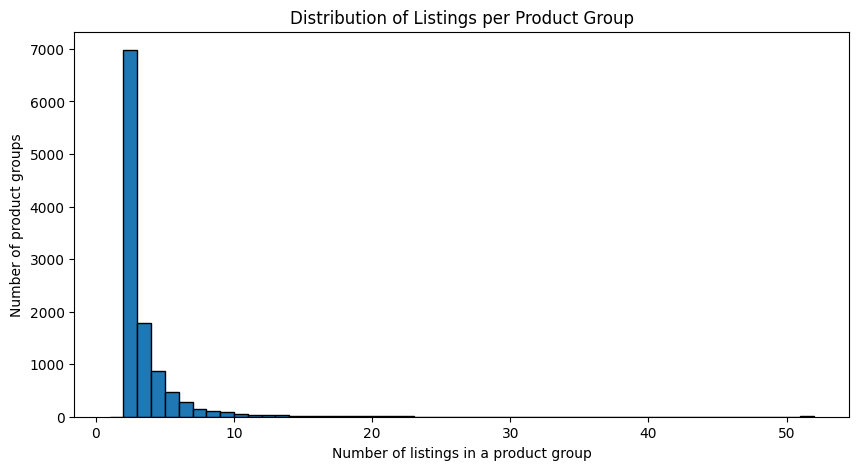

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(group_sizes, bins=range(1, group_sizes.max() + 2), edgecolor="black")
plt.xlabel("Number of listings in a product group")
plt.ylabel("Number of product groups")
plt.title("Distribution of Listings per Product Group")
plt.show()

In [10]:
print("Groups with only 1 listing:", (group_sizes == 1).sum())
print("Groups with >1 listing:", (group_sizes > 1).sum())
print("Largest group:", group_sizes.max())

Groups with only 1 listing: 0
Groups with >1 listing: 11014
Largest group: 51


In [11]:
# How many listings share the exact same image?

image_counts = train["image"].value_counts()

print("Images appearing more than once:",
      (image_counts > 1).sum())

print("Total listings using repeated images:",
      image_counts[image_counts > 1].sum())

print("\nMost repeated images:")
print(image_counts.head(10))

Images appearing more than once: 1246
Total listings using repeated images: 3084

Most repeated images:
image
0cca4afba97e106abd0843ce72881ca4.jpg    15
c739a327dbeca472089a5195e898cce4.jpg    13
5ee62d13d49ea74cc3553f8ba5f6220d.jpg     9
37c48fec3515e5245dff3dfe268b677b.jpg     9
27a805a3f09f52abdc06c063a08e2803.jpg     9
9320d7a2181b28e6a61317e8ca06ffea.jpg     9
92394414388e82ccc782fae516933cb3.jpg     9
2247ba11aff46051df02ec5d386da107.jpg     8
9a061947211680e6475d3b98b477697d.jpg     8
8c01557054b602566075868f3078e3b2.jpg     8
Name: count, dtype: int64


In [12]:
# Do repeated images belong to the same product group?

repeated_images = image_counts[image_counts > 1].index

image_groups = (
    train[train["image"].isin(repeated_images)]
    .groupby("image")["label_group"]
    .nunique()
)

print("Repeated images belonging to >1 product group:",
      (image_groups > 1).sum())

print("Repeated images belonging to exactly 1 product group:",
      (image_groups == 1).sum())

Repeated images belonging to >1 product group: 46
Repeated images belonging to exactly 1 product group: 1200


# So theres basically both so we need to be careful about handling duplicates.

In [13]:
# Showing examples where the exact same image is used across different product groups (46 walla)

cross_group_images = image_groups[image_groups > 1].index

examples = train[train["image"].isin(cross_group_images)].sort_values("image")

print(
    examples[
        ["image", "title", "label_group"]
    ].head(20).to_string(index=False)
)

                               image                                                                                             title  label_group
0c1da0c6bab51f1fe7df75ef060fc77d.jpg                                      Pushop Waistbag Pria Traveling Waterproof Professional Staye   1237550763
0c1da0c6bab51f1fe7df75ef060fc77d.jpg                                                                 Waistbag Pushop Staye Pro Pulshop    109518049
0cca4afba97e106abd0843ce72881ca4.jpg                                                                          bubble wrap - BUBLE WRAP   4198148727
0cca4afba97e106abd0843ce72881ca4.jpg                                             Tambahan Bubble wrap / Plastik Bubble Pelindung paket   4198148727
0cca4afba97e106abd0843ce72881ca4.jpg                                                                              Tambahan Bubble Wrap   4198148727
0cca4afba97e106abd0843ce72881ca4.jpg                                                                      PACKIN

# Now lets do some title analysis

In [14]:
# Title length analysis

train["title_length"] = train["title"].str.len()
train["title_words"] = train["title"].str.split().str.len()

print("Character length:")
print(train["title_length"].describe())

print("\nWord count:")
print(train["title_words"].describe())

Character length:
count    34250.000000
mean        56.163474
std         25.100492
min          5.000000
25%         36.000000
50%         53.000000
75%         73.000000
max        357.000000
Name: title_length, dtype: float64

Word count:
count    34250.000000
mean         9.414861
std          4.446719
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max         61.000000
Name: title_words, dtype: float64


Visualize word counts

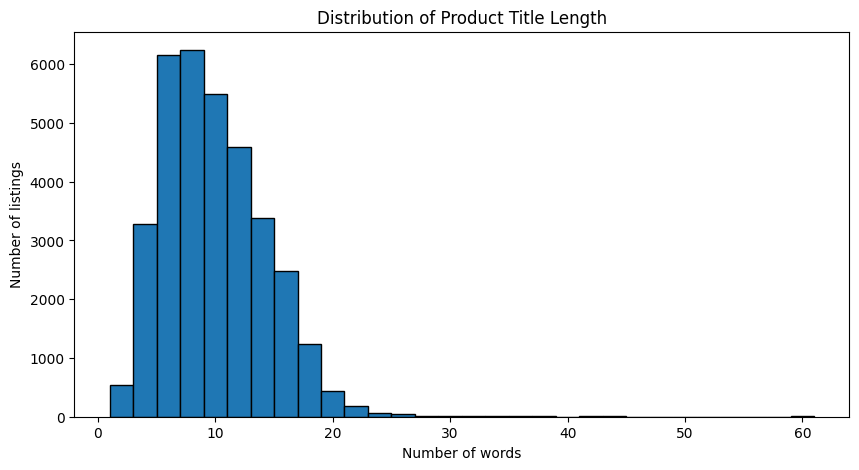

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train["title_words"], bins=30, edgecolor="black")
plt.xlabel("Number of words")
plt.ylabel("Number of listings")
plt.title("Distribution of Product Title Length")
plt.show()

Then check the shortest and longest titles

In [16]:
print("Shortest titles:")
print(train.nsmallest(10, "title_words")[["title", "label_group"]].to_string(index=False))

print("\nLongest titles:")
print(train.nlargest(10, "title_words")[["title", "label_group"]].to_string(index=False))

Shortest titles:
                                    title  label_group
                                  Overall   2612181584
                                 Caviplex   4085784223
                                  Merries    908798147
                                   Nebula   4155543612
                                    fullo   1029271551
                                SIGNATURE   1707910864
                                Freshcare   1821875388
Sepatupria/sepatualphabounce/sepaturuning   3027068648
                                Stimulant   2542461348
                               Mayonnaise   2314234752

Longest titles:
                                                                                                                                                                                                                                                       title  label_group
        Silicone Case Premium Realme 7 7i 5i C15 C12 C17 C11 C2 C3 3 3i 5 6 C1 C3i 5 5S U1 X2 X

In [17]:
title_counts = train["title"].value_counts()

print("Repeated titles:", (title_counts > 1).sum())
print("Listings with repeated titles:", title_counts[title_counts > 1].sum())

print("\nMost repeated titles:")
print(title_counts.head(10))

Repeated titles: 962
Listings with repeated titles: 2095

Most repeated titles:
title
Koko syubbanul muslimin koko azzahir koko baju                                                          9
Baju Koko Pria Gus Azmi Syubbanul Muslimin Kombinasi Hadroh Azzahir Hilw HO187 KEMEJA KOKO PRIA BAJU    8
Monde Boromon Cookies 1 tahun+ 120gr                                                                    6
Viva Air Mawar                                                                                          6
Emina Glossy Stain                                                                                      6
100 Pcs Ikat Rambut Karet Polos Elastis Gaya Korea untuk Wanita                                         6
Shannen lipstik shanen creamy lip paint                                                                 5
Herborist Lulur Tradisional Bali 100gr                                                                  5
Avoskin Miraculous Retinol Toner                                  

# When two listings have exactly the same title, do they actually represent the same product?

In [18]:
repeated_titles = title_counts[title_counts > 1].index

title_groups = (
    train[train["title"].isin(repeated_titles)]
    .groupby("title")["label_group"]
    .nunique()
)

print("Repeated titles belonging to exactly 1 product group:",
      (title_groups == 1).sum())

print("Repeated titles appearing across multiple product groups:",
      (title_groups > 1).sum())

Repeated titles belonging to exactly 1 product group: 889
Repeated titles appearing across multiple product groups: 73


# Lets inspect 73 Cases

In [19]:
# Examples of identical titles used for different products

cross_group_titles = title_groups[title_groups > 1].index

examples = (
    train[train["title"].isin(cross_group_titles)]
    .sort_values("title")
)

print(
    examples[["title", "label_group", "image"]]
    .head(30)
    .to_string(index=False)
)

                                                                                               title  label_group                                image
                                                        (2KG) SHENAR RAK BUKU 3D 1X5 SUSUN ZAMAN NOW   1245245655 7927c658ed2854690d51a7ad0c34f83e.jpg
                                                        (2KG) SHENAR RAK BUKU 3D 1X5 SUSUN ZAMAN NOW   3314259214 c7d5a7303f80ed1eb900120bcd53494f.jpg
                                100Pcs Ikat Karet Rambut Elastis Warna Polos Gaya Korea untuk Wanita   2045845868 a8f94251963c95d2b687fadf4ed9c99a.jpg
                                100Pcs Ikat Karet Rambut Elastis Warna Polos Gaya Korea untuk Wanita    994676122 4e0bad1f97ab9bb4a196511d9c65629c.jpg
                                100Pcs Ikat Karet Rambut Elastis Warna Polos Gaya Korea untuk Wanita    994676122 f6053a4f010a44f006e168a46e78332c.jpg
                                                     ALAT CUKUR RAMBUT / KUMIS / JENGGOT NOVA 

# pHash analysis

In [20]:
phash_counts = train["image_phash"].value_counts()

print("Repeated pHashes:", (phash_counts > 1).sum())
print("Listings with repeated pHashes:",
      phash_counts[phash_counts > 1].sum())

Repeated pHashes: 3229
Listings with repeated pHashes: 8744


In [21]:
repeated_phashes = phash_counts[phash_counts > 1].index

phash_groups = (
    train[train["image_phash"].isin(repeated_phashes)]
    .groupby("image_phash")["label_group"]
    .nunique()
)

print("Repeated pHashes within one product group:",
      (phash_groups == 1).sum())

print("Repeated pHashes across multiple product groups:",
      (phash_groups > 1).sum())

Repeated pHashes within one product group: 3082
Repeated pHashes across multiple product groups: 147


# Example 1: Getting actual product-group examples

In [23]:
# Pick a product group with exactly 3 listings

example_group = (
    train["label_group"]
    .value_counts()
    .loc[lambda x: x == 3]
    .index[0]
)

print(train[train["label_group"] == example_group]
      [["posting_id", "title", "image", "label_group"]]
      .to_string(index=False))

      posting_id                                                                                            title                                image  label_group
train_3505386994                                   YAO YAO Kanaya Outer / Kardigan Moscrepe Polos Rempel Kekinian ee9a2559bf662913f74cf79cf3b32098.jpg     48363793
 train_106977066 RUFFLE CARDIGAN / KARDIGAN WANITA / CARDIGAN WANITA/ OUTER WANITA / KARDIGAN POLOS / OUTER POLOS eebc37f29d5bcd5ee0a632b7376534f4.jpg     48363793
train_2277308546                       1KG MUAT 7PCS || (FREE BELT) KANAYA OUTER / KARDIGAN MOSCREPE POLOS REMPEL f792a55aa2552dbbab4473ebe4f5ea13.jpg     48363793


# Example 2: Same img diff product grps

In [24]:
cross_image_examples = train[
    train["image"].isin(cross_group_images)
]

print(
    cross_image_examples
    [["posting_id", "title", "image", "label_group"]]
    .groupby("image")
    .head(3)
    .head(10)
    .to_string(index=False)
)

      posting_id                                                                                             title                                image  label_group
train_2458596748                                      Pushop Waistbag Pria Traveling Waterproof Professional Staye 0c1da0c6bab51f1fe7df75ef060fc77d.jpg   1237550763
 train_166945100                                                                 Waistbag Pushop Staye Pro Pulshop 0c1da0c6bab51f1fe7df75ef060fc77d.jpg    109518049
train_3068759534                                              BUBBLE PACK UNTUK PACKING TAMBAHAN 1BUBBLE UNTUK 1KG 0cca4afba97e106abd0843ce72881ca4.jpg   4198148727
train_1049463374                                                                                       BUBBLE WARP 0cca4afba97e106abd0843ce72881ca4.jpg   2403374241
train_2420615645                                                     BUBBLE WRAP - EXTRA PACKING UNTUK BARANG ANDA 0cca4afba97e106abd0843ce72881ca4.jpg   4198148727
train_2308

# Example 3: Same title, different product groups

In [25]:
print(
    train[train["title"].isin(cross_group_titles)]
    [["posting_id", "title", "image", "label_group"]]
    .groupby("title")
    .head(2)
    .head(10)
    .to_string(index=False)
)

      posting_id                                                                                              title                                image  label_group
train_2406599165 Daster Batik Lengan pendek - Motif Acak / Campur - Leher Kancing (DPT001-00) Batik karakter Alhadi 00117e4fc239b1b641ff08340b429633.jpg   4093212188
 train_615566263                                                  TUNIK DZUVIA KANCING HIDUP SYARI MOSCREPE PREMIUM 007fca8ce9a042f9e1656ce8f96ba19d.jpg   1356633425
 train_588233376                                                                              Viva Air Mawar 100 ml 02a399bafca7fa660b35b925f6d3e6fb.jpg   3813608589
train_2690347138                                                                                    Madu Uray 640ml 04adc9307baf0e7fa76713a851d3fbc3.jpg   1674683146
 train_867713168                               WIRELESS STEREO AUDIO RECEIVER BLUETOOTH ADAPTER USB / USB BLUETOOTH 050a3439e9c246b5edc64962e587ac6f.jpg    800610000
 tra

# Finally getting visual examples

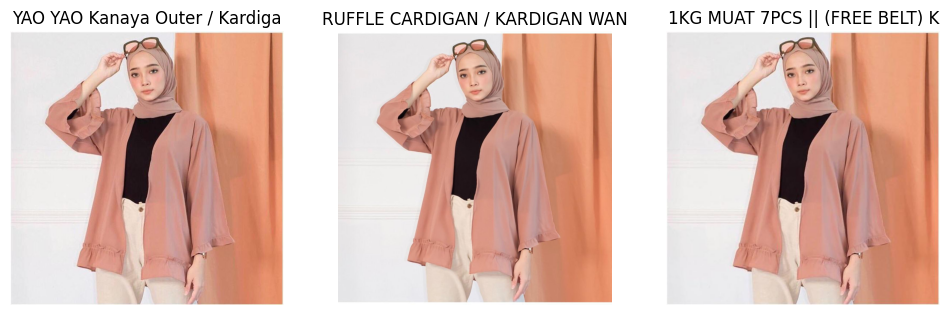

In [26]:
from PIL import Image
import matplotlib.pyplot as plt
import os

IMAGE_PATH = f"{DATA_PATH}/train_images"

rows = train[train["label_group"] == example_group].head(3)

plt.figure(figsize=(12, 4))

for i, (_, row) in enumerate(rows.iterrows()):
    img = Image.open(os.path.join(IMAGE_PATH, row["image"]))

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(row["title"][:30])

plt.show()